# Fig 2b: pairwise model comparison statistics

All pairwise comparisons on matched bootstrap runs for:
- **Batch mixing score** (`batch_ASW`)
- **kNN label F1** (`kNN_label_f1_macro`)

Models with *continual* or *full* variants are excluded. Each metric is analysed separately:
one summary heatmap per metric (signed mean difference + significance border), plus paired slope plots for every model pair.

In [9]:
import itertools
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

%run analysis_utils.py
%run fig2_plot_utils.py

RESULTS_PATH = os.path.expanduser(
    '~/scFM_eval/results/embedding_bootstrap/embedding.metrics.bootstrap.csv'
)
OUTPUT_DIR = "./fig3_metrics"
PLOT_DIR = "./plots"
SLOPE_DIR = os.path.join(PLOT_DIR, "pair_slopes")

METRICS = {
    "batch_ASW": "Batch mixing score",
    "kNN_label_f1_macro": "kNN label F1",
}

GROUP_ORDER = ["Baseline", "Geneformer", "Other", "scGPT"]
GROUP_COLORS = {
    "Baseline": "#1f77b4",
    "Geneformer": "#ff7f0e",
    "scGPT": "#2ca02c",
    "Other": "#7f7f7f",
}

results = pd.read_csv(RESULTS_PATH)

exclude = (
    results.model_display.str.contains("continue", case=False)
    | results.model_display.str.contains("Full", case=False)
    | results.model.str.contains("continue", case=False)
    | results.model.str.contains("^full_", case=False, regex=True)
)
df = results.loc[~exclude].copy()

model_meta = (
    df[["model", "model_display", "group"]]
    .drop_duplicates("model")
    .set_index("model")
)
models = sorted(model_meta.index)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(SLOPE_DIR, exist_ok=True)

print(f"Models included: {len(models)}")
print(model_meta["model_display"].tolist())
print(f"Pairwise comparisons per metric: {len(list(itertools.combinations(models, 2)))}")


Models included: 17
['STATE', 'scVI', 'SCimiarity', 'scGPT', 'scGPT [cancer]', 'scFoundation', 'scConcept', 'PCA [50]', 'PCA [20]', 'PCA [100]', 'Nicheformer', 'HVG', 'GF-V2-Deep', 'GF-V2 [cancer]', 'GF-V2', 'GF-V1', 'CellPLM']
Pairwise comparisons per metric: 136


In [10]:
def slugify(text):
    return re.sub(r"[^a-zA-Z0-9]+", "_", text).strip("_").lower()


def paired_metric_values(df, metric, model_a, model_b):
    a = df[df["model"] == model_a].set_index("run")[metric].sort_index()
    b = df[df["model"] == model_b].set_index("run")[metric].sort_index()
    runs = a.index.intersection(b.index)
    return a.loc[runs], b.loc[runs], runs


def ordered_methods(df, metric, models):
    means = df.groupby("model_display")[metric].mean()
    labels = [model_meta.loc[m, "model_display"] for m in models]
    return means.loc[labels].sort_values(ascending=False).index.tolist()


def pairwise_stats(df, metric, models):
    rows = []
    for model_a, model_b in itertools.combinations(models, 2):
        vals_a, vals_b, runs = paired_metric_values(df, metric, model_a, model_b)
        diff = vals_b - vals_a
        _, wilcoxon_p = stats.wilcoxon(vals_b, vals_a)
        _, t_p = stats.ttest_rel(vals_b, vals_a)
        label_a = model_meta.loc[model_a, "model_display"]
        label_b = model_meta.loc[model_b, "model_display"]
        rows.append(
            {
                "metric": metric,
                "model_a": model_a,
                "model_b": model_b,
                "label_a": label_a,
                "label_b": label_b,
                "group_a": model_meta.loc[model_a, "group"],
                "group_b": model_meta.loc[model_b, "group"],
                "n_pairs": len(runs),
                "mean_a": vals_a.mean(),
                "mean_b": vals_b.mean(),
                "mean_diff_b_minus_a": diff.mean(),
                "wilcoxon_p": wilcoxon_p,
                "paired_t_p": t_p,
            }
        )

    out = pd.DataFrame(rows)
    _, fdr_p, _, _ = multipletests(out["wilcoxon_p"], method="fdr_bh")
    out["fdr_p"] = fdr_p
    out["significant"] = out["fdr_p"] < 0.05
    out["direction"] = np.where(out["mean_diff_b_minus_a"] > 0, ">", "<")
    return out


def _pairwise_matrices(pairwise_df, ordered_labels, fdr_threshold=0.05):
    diff = pd.DataFrame(np.nan, index=ordered_labels, columns=ordered_labels)
    sig = pd.DataFrame(False, index=ordered_labels, columns=ordered_labels)

    for _, row in pairwise_df.iterrows():
        la, lb = row["label_a"], row["label_b"]
        ma, mb = row["mean_a"], row["mean_b"]
        ia, ib = ordered_labels.index(la), ordered_labels.index(lb)
        row_label, col_label = ordered_labels[ia], ordered_labels[ib]
        if ia > ib:
            row_label, col_label = lb, la
            ma, mb = mb, ma
        diff.loc[row_label, col_label] = ma - mb
        sig.loc[row_label, col_label] = row["fdr_p"] < fdr_threshold

    return diff, sig


def plot_pairwise_heatmap(
    pairwise_df,
    ordered_labels,
    metric_label,
    save_path=None,
    fdr_threshold=0.05,
    higher_is_better=True,
):
    """Upper-triangle heatmap: cell = row mean − column mean.

    Color shows effect size (blue = row model better when higher_is_better).
    Black border marks FDR < fdr_threshold.
    """
    from matplotlib.patches import Rectangle

    apply_publication_style()

    diff_data, sig_data = _pairwise_matrices(pairwise_df, ordered_labels, fdr_threshold)
    ranked_labels = [f"{i + 1}. {label}" for i, label in enumerate(ordered_labels)]

    n = len(ordered_labels)
    figsize = (max(10, 0.55 * n), max(9, 0.55 * n))
    fig, ax = plt.subplots(figsize=figsize)

    upper_tri = np.triu(np.ones_like(diff_data, dtype=bool), k=1)
    lower_tri = ~upper_tri
    vmax = np.nanmax(np.abs(diff_data.values[upper_tri]))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0

    # RdBu_r: red = negative (column wins), blue = positive (row wins)
    cmap = plt.get_cmap("RdBu_r") if higher_is_better else plt.get_cmap("RdBu")
    sns.heatmap(
        diff_data,
        mask=lower_tri,
        cmap=cmap,
        center=0,
        vmin=-vmax,
        vmax=vmax,
        cbar_kws={"label": "Row mean − column mean"},
        linewidths=0.5,
        linecolor="#DDDDDD",
        square=True,
        ax=ax,
    )

    for i, row_label in enumerate(ordered_labels):
        for j, col_label in enumerate(ordered_labels):
            if j <= i:
                continue
            delta = diff_data.loc[row_label, col_label]
            if pd.isna(delta):
                continue
            is_sig = sig_data.loc[row_label, col_label]
            if is_sig:
                ax.add_patch(
                    Rectangle(
                        (j, i), 1, 1, fill=False, edgecolor="#111111", linewidth=2.0, zorder=4
                    )
                )
            text_color = "white" if abs(delta) > 0.55 * vmax else "#333333"
            ax.text(
                j + 0.5,
                i + 0.5,
                f"{delta:+.3f}",
                ha="center",
                va="center",
                fontsize=6,
                color=text_color,
                zorder=5,
            )

    ax.set_xticks(np.arange(n) + 0.5)
    ax.set_yticks(np.arange(n) + 0.5)
    ax.set_xticklabels(ranked_labels, rotation=90)
    ax.set_yticklabels(ranked_labels, rotation=0)
    for tick in ax.get_xticklabels():
        label = tick.get_text().split(". ", 1)[-1]
        group = df.loc[df["model_display"] == label, "group"].iloc[0]
        tick.set_color(GROUP_COLORS.get(group, "#333333"))
    for tick in ax.get_yticklabels():
        label = tick.get_text().split(". ", 1)[-1]
        group = df.loc[df["model_display"] == label, "group"].iloc[0]
        tick.set_color(GROUP_COLORS.get(group, "#333333"))

    direction_note = "higher is better" if higher_is_better else "lower is better"
    winner_note = "blue = row model better" if higher_is_better else "blue = row model lower"
    ax.set_xlabel("Column model (ranked by mean score)")
    ax.set_ylabel("Row model (ranked by mean score)")
    ax.set_title(
        f"Pairwise comparisons: {metric_label} ({direction_note})\n"
        f"Cell = row − column mean; {winner_note}; black border = FDR < {fdr_threshold}"
    )
    fig.tight_layout()
    
    if save_path:
        save_publication_figure(fig, save_path)

    return fig, ax


def plot_paired_slope(df, metric, model_a, model_b, metric_label, save_path=None):
    apply_publication_style()

    vals_a, vals_b, _ = paired_metric_values(df, metric, model_a, model_b)
    label_a = model_meta.loc[model_a, "model_display"]
    label_b = model_meta.loc[model_b, "model_display"]

    fig, ax = plt.subplots(figsize=(3.2, 4.5))
    x_a, x_b = 0, 1
    color_a, color_b = "#4C78A8", "#F58518"

    for a, b in zip(vals_a, vals_b):
        ax.plot([x_a, x_b], [a, b], color="#B0B7C3", linewidth=0.9, alpha=0.7, zorder=1)

    ax.scatter([x_a] * len(vals_a), vals_a, color=color_a, s=28, zorder=2, label=label_a)
    ax.scatter([x_b] * len(vals_b), vals_b, color=color_b, s=28, zorder=2, label=label_b)
    ax.scatter([x_a], [vals_a.mean()], color=color_a, s=70, marker="D", zorder=3)
    ax.scatter([x_b], [vals_b.mean()], color=color_b, s=70, marker="D", zorder=3)

    ax.set_xticks([x_a, x_b])
    ax.set_xticklabels([label_a, label_b], rotation=25, ha="right")
    ax.set_title(metric_label, fontsize=10)
    ax.set_xlim(-0.35, 1.35)
    ax.grid(axis="y", color="#E5E5E5", linewidth=0.6)
    ax.set_axisbelow(True)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.12), frameon=False, fontsize=8)
    ax.get_legend().remove()
    fig.tight_layout()

    if save_path:
        save_publication_figure(fig, save_path)

    return fig, ax


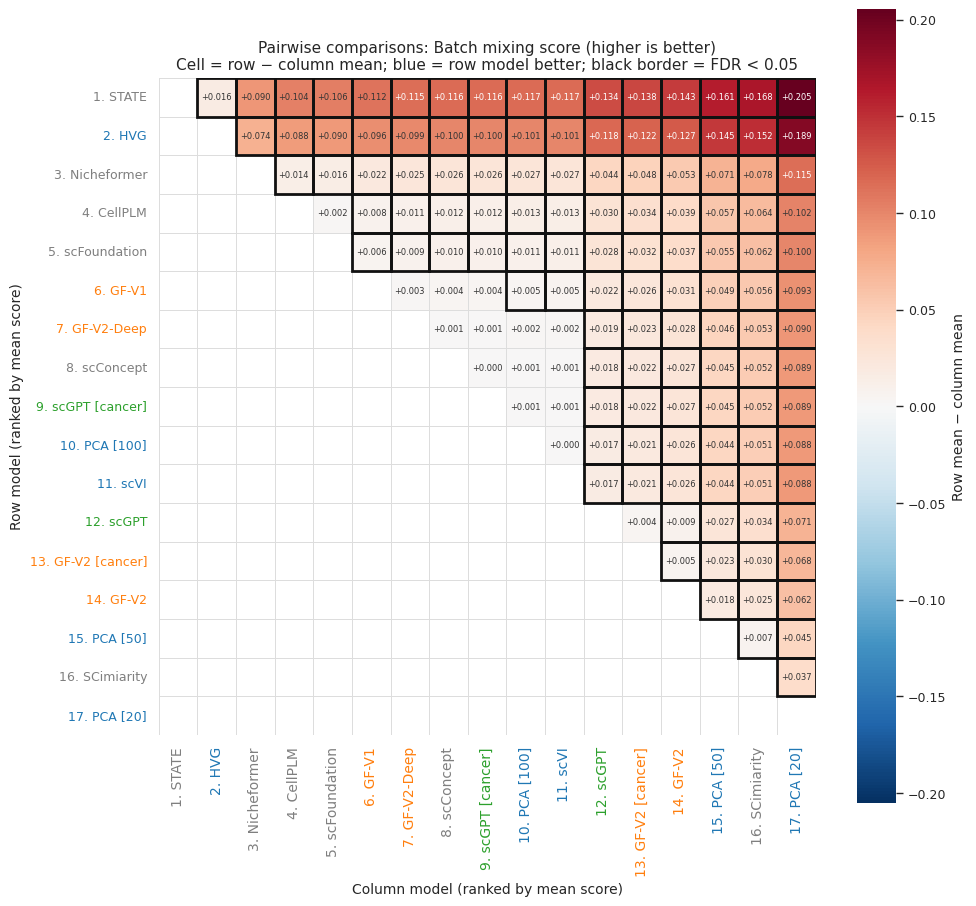

Batch mixing score: 121/136 pairs significant (FDR < 0.05)
  saved stats -> ./fig3_metrics/pairwise_batch_ASW.csv
  saved heatmap -> ./plots/pairwise_heatmap_batch_ASW.png


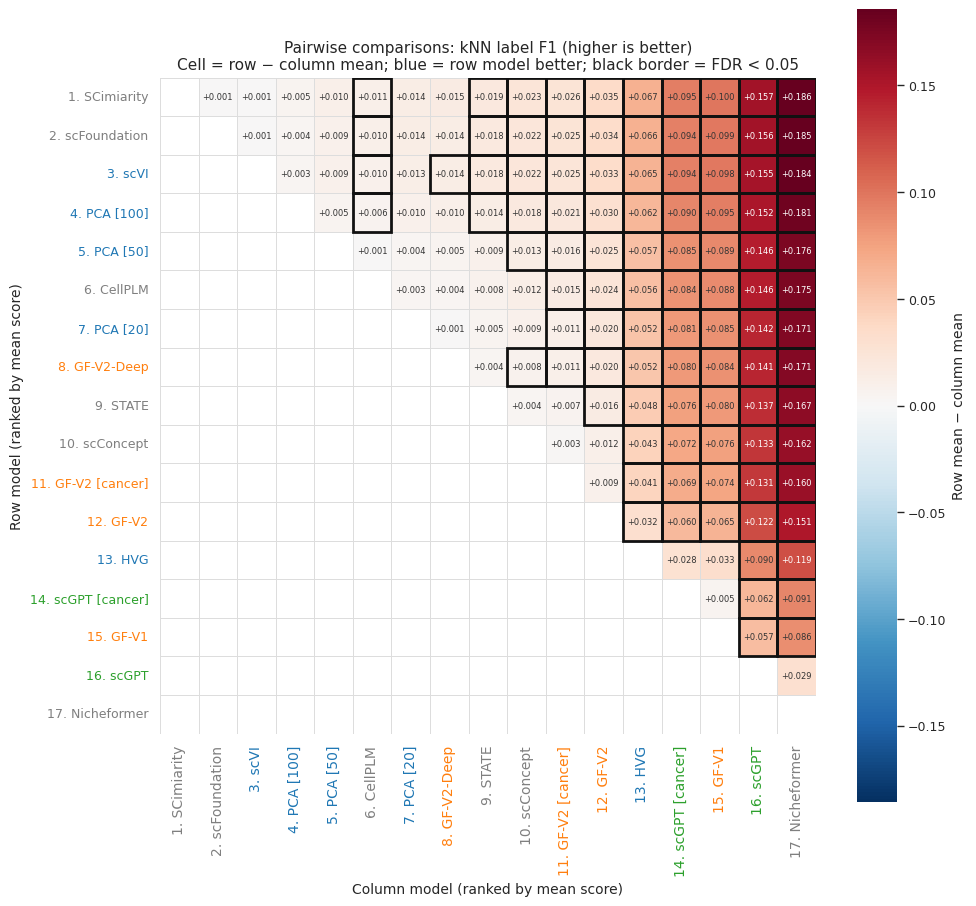

kNN label F1: 98/136 pairs significant (FDR < 0.05)
  saved stats -> ./fig3_metrics/pairwise_kNN_label_f1_macro.csv
  saved heatmap -> ./plots/pairwise_heatmap_kNN_label_f1_macro.png


In [11]:
pairwise_by_metric = {}
ordered_by_metric = {}

for metric, metric_label in METRICS.items():
    pairwise_df = pairwise_stats(df, metric, models)
    ordered_labels = ordered_methods(df, metric, models)

    pairwise_by_metric[metric] = pairwise_df
    ordered_by_metric[metric] = ordered_labels

    csv_path = os.path.join(OUTPUT_DIR, f"pairwise_{metric}.csv")
    pairwise_df.to_csv(csv_path, index=False)

    heatmap_path = os.path.join(PLOT_DIR, f"pairwise_heatmap_{metric}.png")
    fig, ax = plot_pairwise_heatmap(
        pairwise_df,
        ordered_labels,
        metric_label,
        save_path=heatmap_path,
    )
    plt.show()
    plt.close(fig)

    n_sig = pairwise_df["significant"].sum()
    print(f"{metric_label}: {n_sig}/{len(pairwise_df)} pairs significant (FDR < 0.05)")
    print(f"  saved stats -> {csv_path}")
    print(f"  saved heatmap -> {heatmap_path}")


In [12]:
SAVE_SLOPE_PLOTS = True

for metric, metric_label in METRICS.items():
    metric_slope_dir = os.path.join(SLOPE_DIR, metric)
    os.makedirs(metric_slope_dir, exist_ok=True)

    for model_a, model_b in itertools.combinations(models, 2):
        label_a = model_meta.loc[model_a, "model_display"]
        label_b = model_meta.loc[model_b, "model_display"]
        filename = f"{slugify(label_a)}_vs_{slugify(label_b)}.png"
        save_path = os.path.join(metric_slope_dir, filename) if SAVE_SLOPE_PLOTS else None

        fig, ax = plot_paired_slope(
            df,
            metric,
            model_a,
            model_b,
            metric_label,
            save_path=save_path,
        )
        
        plt.close(fig)

    print(f"Saved {len(list(itertools.combinations(models, 2)))} slope plots for {metric_label} -> {metric_slope_dir}")


Saved 136 slope plots for Batch mixing score -> ./plots/pair_slopes/batch_ASW
Saved 136 slope plots for kNN label F1 -> ./plots/pair_slopes/kNN_label_f1_macro


AttributeError: 'NoneType' object has no attribute 'remove'

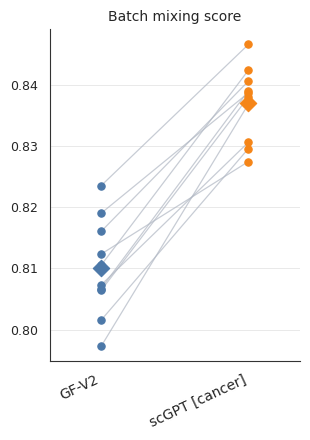

In [13]:
# Preview a single pair (edit labels as needed)
PREVIEW_LABEL_A = "GF-V2"
PREVIEW_LABEL_B = "scGPT [cancer]"
PREVIEW_METRIC = "batch_ASW"

preview_a = model_meta[model_meta["model_display"] == PREVIEW_LABEL_A].index[0]
preview_b = model_meta[model_meta["model_display"] == PREVIEW_LABEL_B].index[0]

fig, ax = plot_paired_slope(
    df,
    PREVIEW_METRIC,
    preview_a,
    preview_b,
    METRICS[PREVIEW_METRIC],
)
ax.get_legend().remove()
plt.show()
